In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualización
sns.set_style("whitegrid")
plt.style.use("ggplot")
sns.set(font_scale=1.1)
from google.colab import drive

In [76]:
drive.mount('/content/drive')
DATA_DIR = '/content/drive/My Drive/AnaL'
OUTPUT_DIR = '/content/drive/My Drive/AnaL'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
data_file = os.path.join(DATA_DIR, "BD_IPSA_1940.xlsx")

df = pd.read_excel(data_file)

# EDA

In [30]:
df.columns = [col.lower().strip().replace(" ", "_").replace("%", "pct_") for col in df.columns]
print("Primeras filas del dataset:")
print(df.head())

Primeras filas del dataset:
   unnamed:_0          nome    faz tal         tipocorte   variedad madurada  \
0          11  AMAIME SILCA  81291  40  Mecanizado Verde  CC01-1940       SI   
1          12  AMAIME SILCA  81291  41  Mecanizado Verde  CC01-1940       SI   
2          13  AMAIME SILCA  81291  41  Mecanizado Verde  CC01-1940       SI   
3          15  AMAIME SILCA  81291  43  Mecanizado Verde  CC01-1940       SI   
4          16  AMAIME SILCA  81291  43  Mecanizado Verde  CC01-1940       SI   

                             producto  dosismad  semsmad  ...  cortes    me  \
0  BONUS 250 EC REGULADOR FISIOLÓGICO       0.8      8.3  ...       4  12.7   
1  BONUS 250 EC REGULADOR FISIOLÓGICO       0.8      6.3  ...       2   7.8   
2  BONUS 250 EC REGULADOR FISIOLÓGICO       0.6      7.9  ...       3   8.8   
3  BONUS 250 EC REGULADOR FISIOLÓGICO       0.8      6.6  ...       1   6.1   
4  BONUS 250 EC REGULADOR FISIOLÓGICO       0.6      8.1  ...       2   7.9   

   vejez  sacaro

In [31]:
print("Información del DataFrame:")
df.info()

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unnamed:_0      2187 non-null   int64  
 1   nome            2187 non-null   object 
 2   faz             2187 non-null   int64  
 3   tal             2187 non-null   object 
 4   tipocorte       2187 non-null   object 
 5   variedad        2187 non-null   object 
 6   madurada        2187 non-null   object 
 7   producto        2187 non-null   object 
 8   dosismad        2187 non-null   float64
 9   semsmad         2187 non-null   float64
 10  edad            2187 non-null   float64
 11  cortes          2187 non-null   int64  
 12  me              2187 non-null   float64
 13  vejez           2187 non-null   float64
 14  sacarosa        2187 non-null   float64
 15  mes             2187 non-null   int64  
 16  periodo         2187 non-null   int64  
 17  tch   

In [32]:
print("Resumen Estadístico de Variables Numéricas:")
desc_stats = df.describe()
print(desc_stats)

Resumen Estadístico de Variables Numéricas:
        unnamed:_0           faz     dosismad      semsmad         edad  \
count  2187.000000   2187.000000  2187.000000  2187.000000  2187.000000   
mean   2126.506630  80588.332876     0.993278     9.164838    12.766118   
std    1228.561661    572.818299     0.309096     3.441579     1.117866   
min      11.000000  80100.000000     0.000000    -1.600000    10.300000   
25%    1038.000000  80222.000000     0.800000     7.100000    12.000000   
50%    2219.000000  80396.000000     1.000000     8.700000    12.500000   
75%    3223.500000  80660.000000     1.200000    10.600000    13.300000   
max    4222.000000  82519.000000     9.000000    45.000000    21.100000   

            cortes           me        vejez     sacarosa          mes  \
count  2187.000000  2187.000000  2187.000000  2187.000000  2187.000000   
mean      2.794239     9.197759     4.172154    12.777732     6.758573   
std       1.621195     1.574409     6.339255     0.854397 

In [33]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("\nVariables numéricas:", numeric_columns)
print("Variables categóricas:", categorical_columns)


Variables numéricas: ['unnamed:_0', 'faz', 'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez', 'sacarosa', 'mes', 'periodo', 'tch', 'lluvias', 'grupo_tenencia', 'pct_diatrea']
Variables categóricas: ['nome', 'tal', 'tipocorte', 'variedad', 'madurada', 'producto']


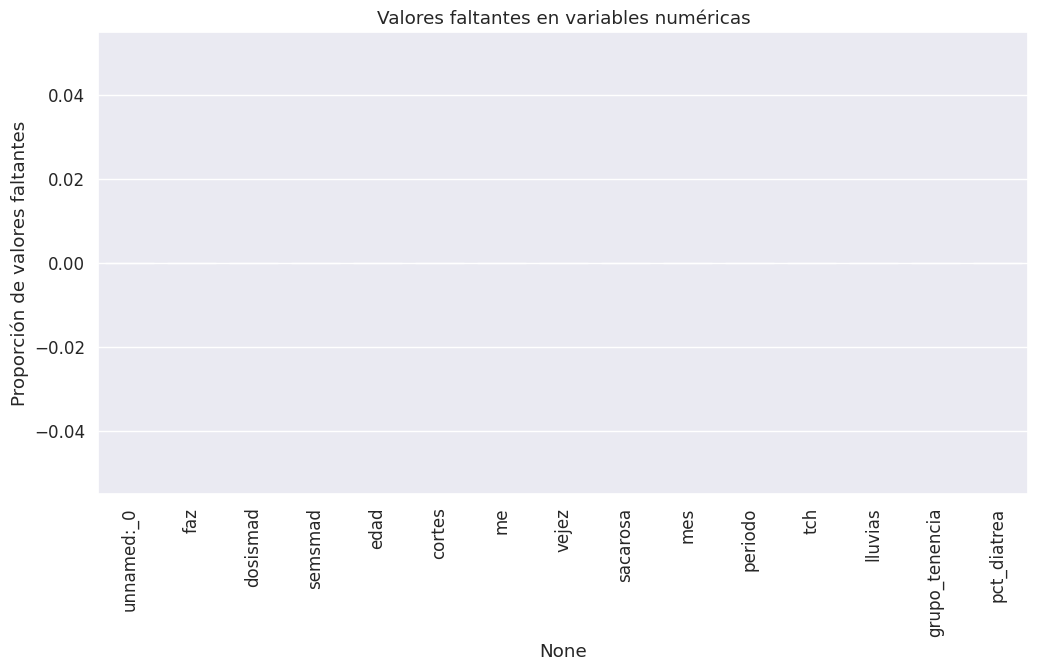

In [34]:
missing_numeric = df[numeric_columns].isnull().mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_numeric.index, y=missing_numeric.values, color='red')
plt.xticks(rotation=90)
plt.ylabel("Proporción de valores faltantes")
plt.title("Valores faltantes en variables numéricas")
plt.show()

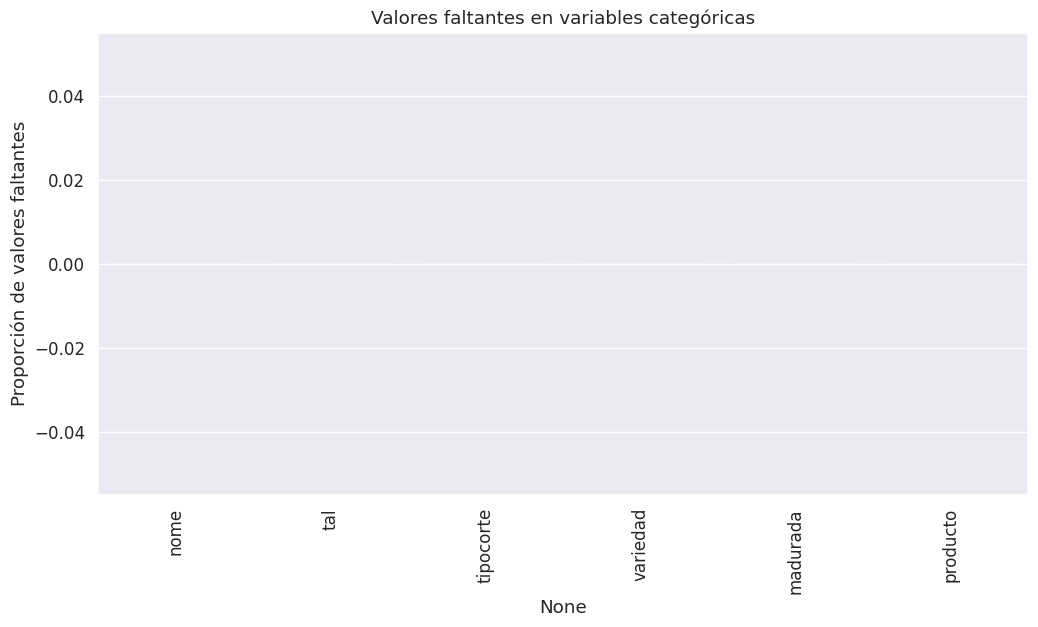

In [35]:
missing_categorical = df[categorical_columns].isnull().mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_categorical.index, y=missing_categorical.values, color='blue')
plt.xticks(rotation=90)
plt.ylabel("Proporción de valores faltantes")
plt.title("Valores faltantes en variables categóricas")
plt.show()

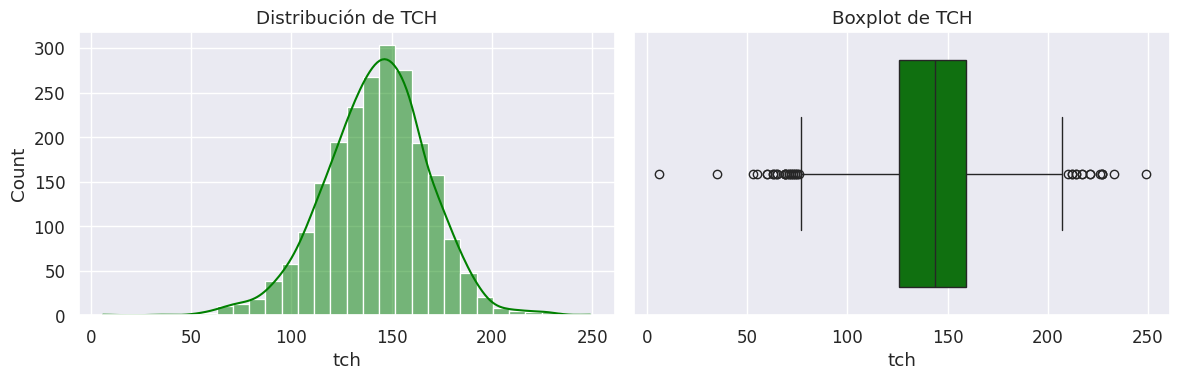

In [36]:
# Histograma y boxplot para TCH
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
sns.histplot(df['tch'], bins=30, kde=True, color='green')
plt.title("Distribución de TCH")

plt.subplot(1,2,2)
sns.boxplot(x=df['tch'], color='green')
plt.title("Boxplot de TCH")
plt.tight_layout()
plt.show()

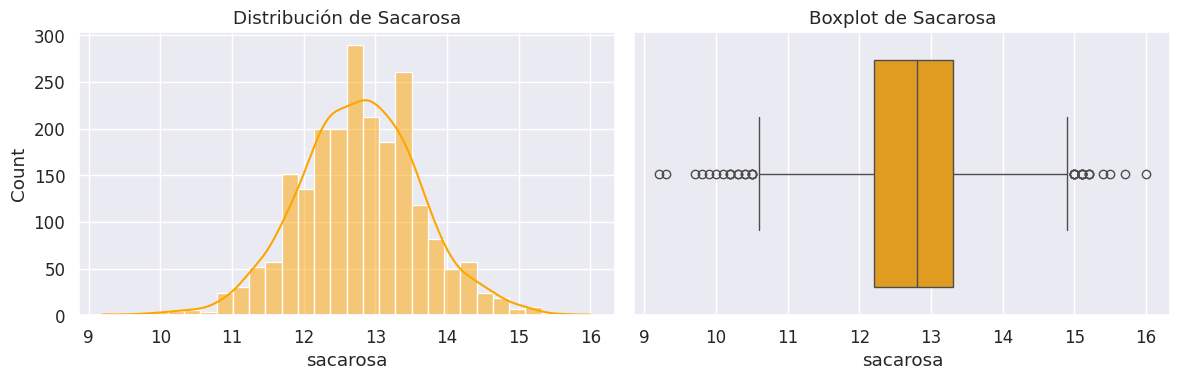

In [39]:
# Lo mismo pero para el Porcentaje de Sacarosa
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
sns.histplot(df['sacarosa'], bins=30, kde=True, color='orange')
plt.title("Distribución de Sacarosa")

plt.subplot(1,2,2)
sns.boxplot(x=df['sacarosa'], color='orange')
plt.title("Boxplot de Sacarosa")
plt.tight_layout()
plt.show()

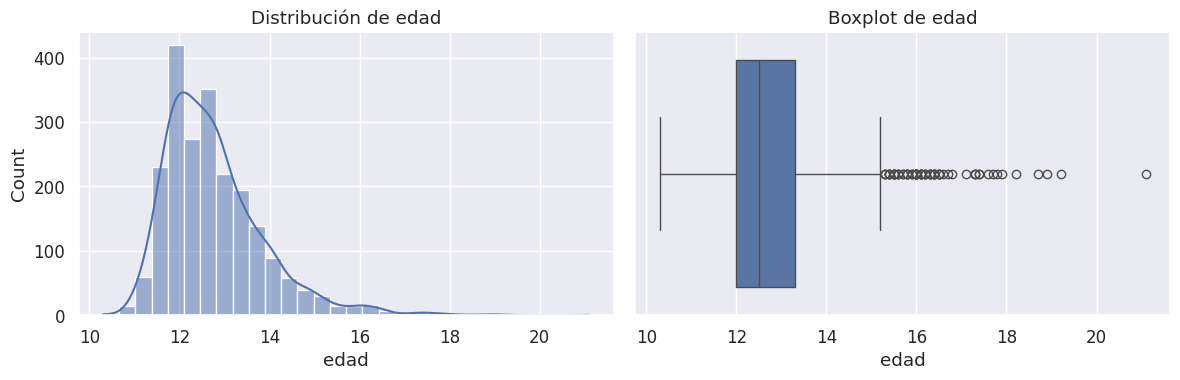

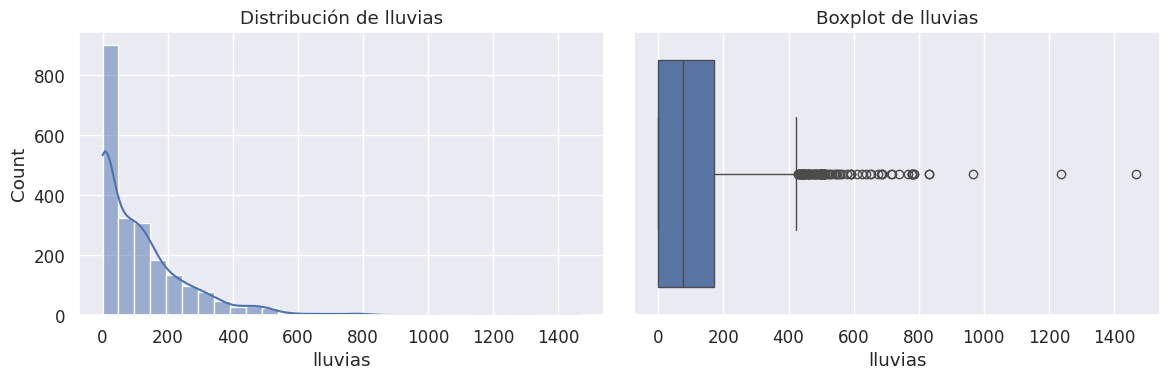

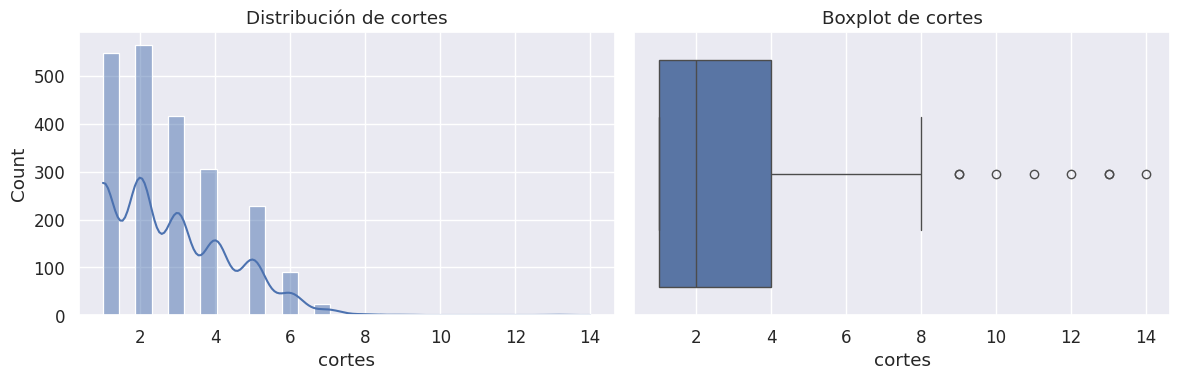

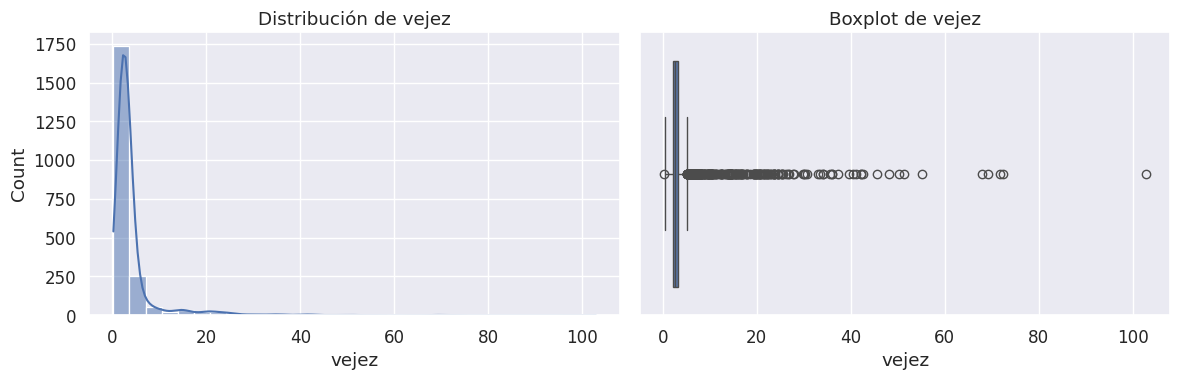

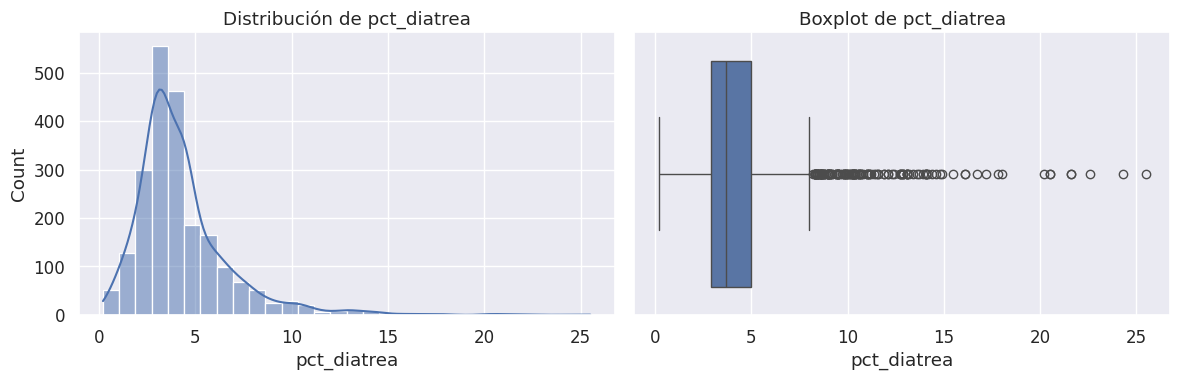

In [40]:
otras_numericas = ['edad', 'lluvias', 'cortes', 'vejez', 'pct_diatrea']
for col in otras_numericas:
    if col in df.columns:
        plt.figure(figsize=(12, 4))
        plt.subplot(1,2,1)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Distribución de {col}")

        plt.subplot(1,2,2)
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot de {col}")
        plt.tight_layout()
        plt.show()

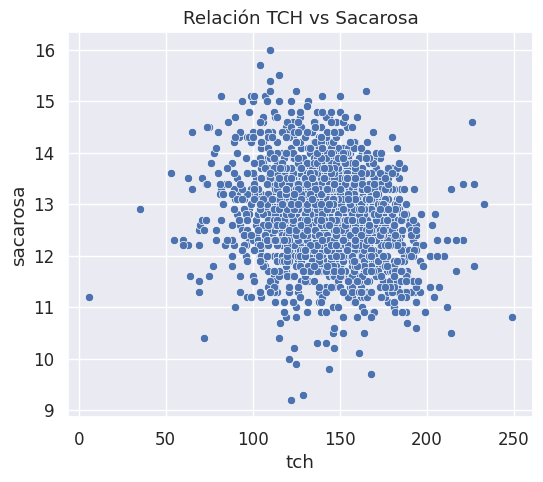

In [41]:
# Relación entre TCH y sacarosa
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='tch', y='sacarosa')
plt.title("Relación TCH vs Sacarosa")
plt.show()


In [43]:
# Columnas numéricas y categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

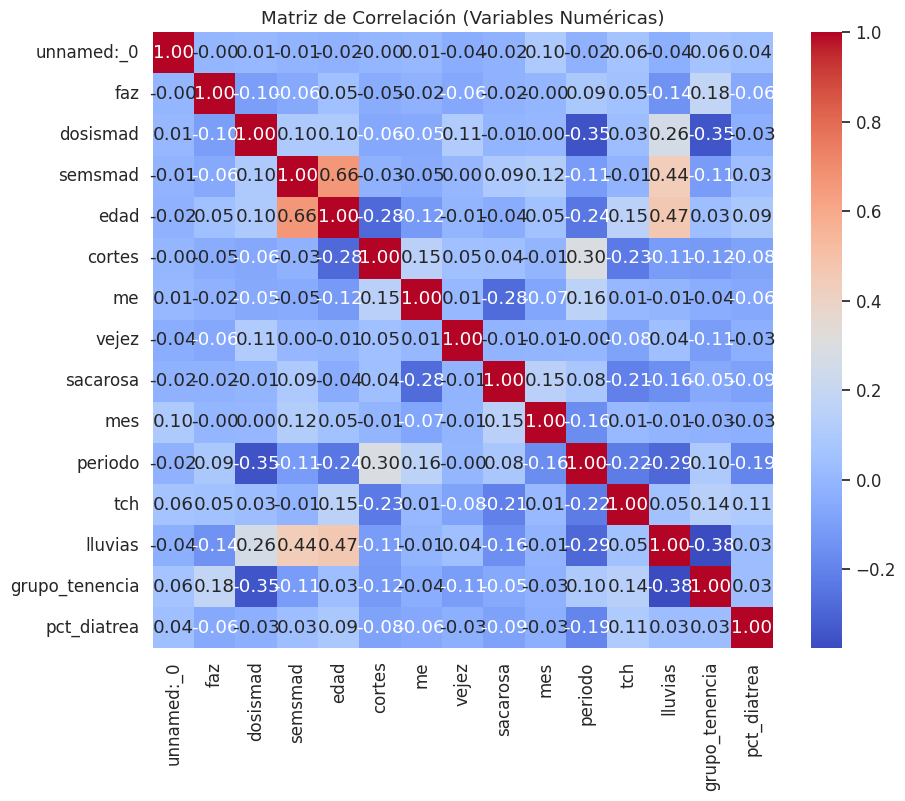

In [44]:
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.show()


Frecuencia de categorías en 'nome':
nome
SAN MIGUEL CARVAJAL    101
SANTA ANA               65
MARSELLA                48
EL ALBION               41
VILLA INES              36
                      ... 
EL LIBANO 3              1
EL ENCANTO               1
EL CARMEN                1
EL CARMEN VELASCO        1
EL DANUBIO C             1
Name: count, Length: 285, dtype: int64


<ipython-input-51-d3a2c7474f57>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', order=df[col].value_counts().index)


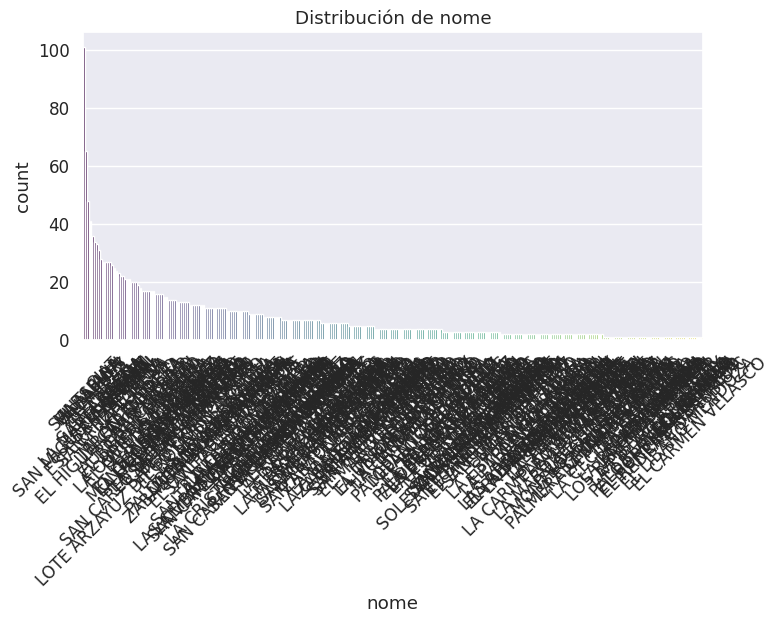


Frecuencia de categorías en 'tal':
tal
1       258
2       191
3       154
4       149
5       108
       ... 
003E      1
007D      1
005D      1
006D      1
545A      1
Name: count, Length: 273, dtype: int64


<ipython-input-51-d3a2c7474f57>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', order=df[col].value_counts().index)


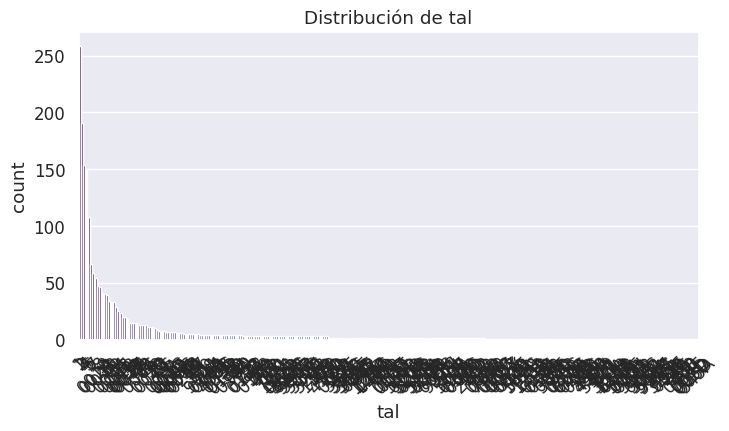


Frecuencia de categorías en 'tipocorte':
tipocorte
Mecanizado Verde    2187
Name: count, dtype: int64


<ipython-input-51-d3a2c7474f57>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', order=df[col].value_counts().index)


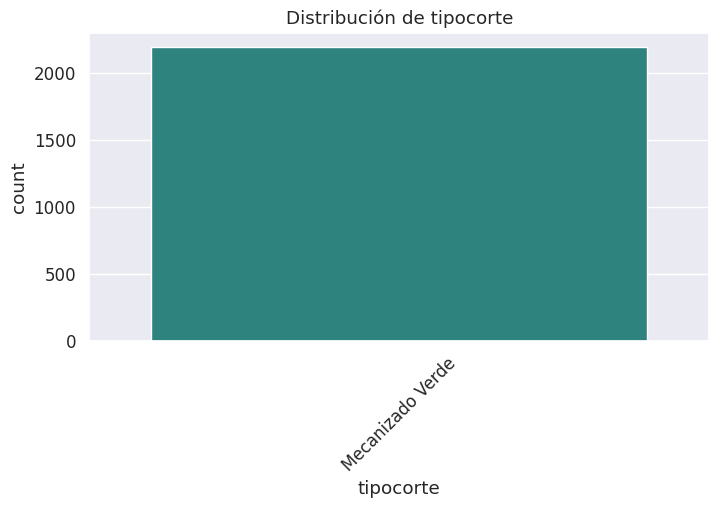


Frecuencia de categorías en 'variedad':
variedad
CC01-1940    2187
Name: count, dtype: int64


<ipython-input-51-d3a2c7474f57>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', order=df[col].value_counts().index)


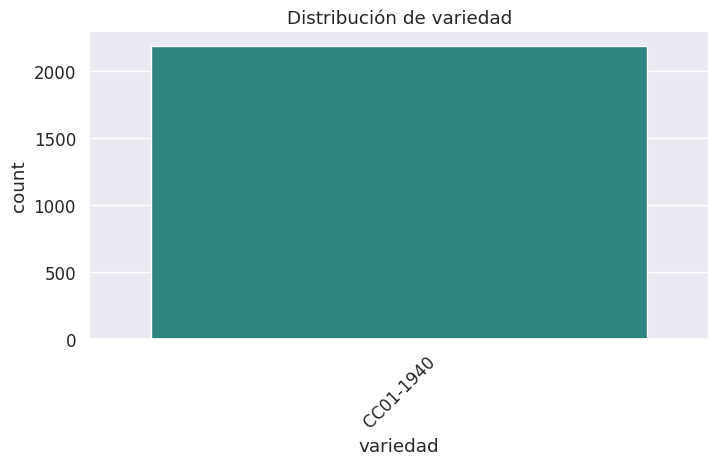


Frecuencia de categorías en 'madurada':
madurada
SI    2187
Name: count, dtype: int64


<ipython-input-51-d3a2c7474f57>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', order=df[col].value_counts().index)


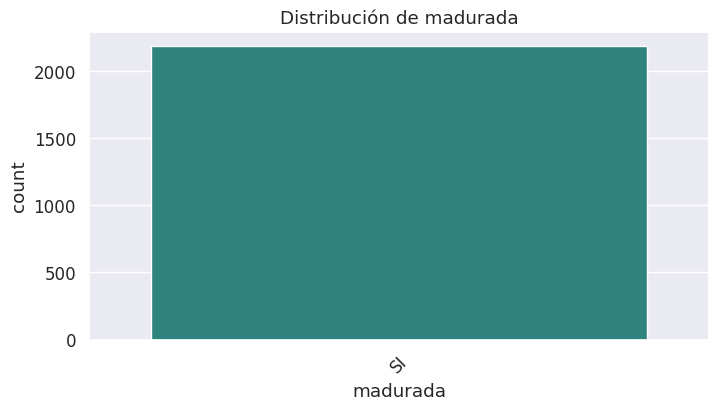


Frecuencia de categorías en 'producto':
producto
BONUS 250 EC REGULADOR FISIOLÓGICO    2187
Name: count, dtype: int64


<ipython-input-51-d3a2c7474f57>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis', order=df[col].value_counts().index)


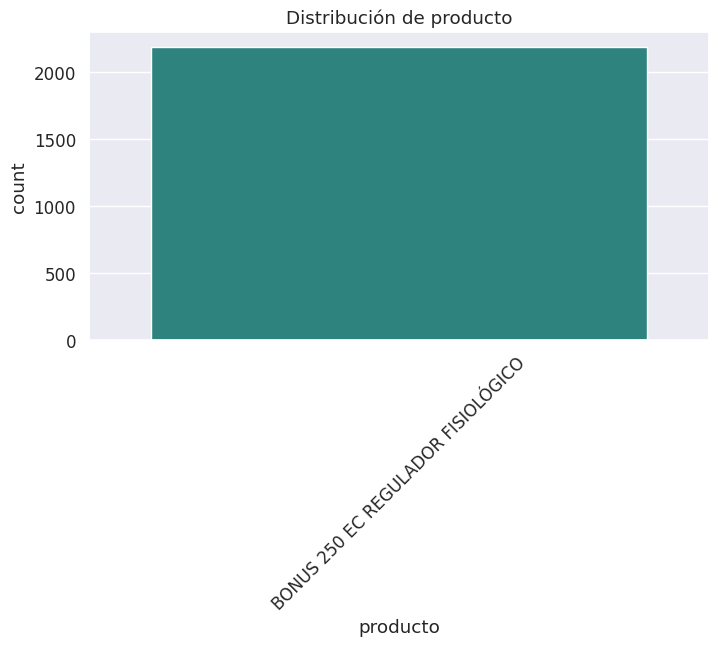

In [51]:
for col in cat_cols:
    print(f"\nFrecuencia de categorías en '{col}':")
    print(df[col].value_counts(dropna=False))

    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col], palette='viridis', order=df[col].value_counts().index)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.show()

# Division en niveles las columans de sacarosa y tch

In [59]:
# Para TCH
tch_labels = ['bajo', 'medio', 'alto']
# Al crear las categorías, además de asignar las etiquetas, obtenemos los bins
tch_categories, tch_bins = pd.qcut(df['tch'], q=3, labels=tch_labels, retbins=True)

# Para Sacarosa
sacarosa_labels = ['bajo', 'medio', 'alto']
sacarosa_categories, sacarosa_bins = pd.qcut(df['sacarosa'], q=3, labels=sacarosa_labels, retbins=True)

print("Rangos numéricos para TCH:")
print(f"Bajo: desde {tch_bins[0]:.2f} hasta {tch_bins[1]:.2f}")
print(f"Medio: desde {tch_bins[1]:.2f} hasta {tch_bins[2]:.2f}")
print(f"Alto: desde {tch_bins[2]:.2f} hasta {tch_bins[3]:.2f}")

print("\nRangos numéricos para Sacarosa:")
print(f"Bajo: desde {sacarosa_bins[0]:.2f} hasta {sacarosa_bins[1]:.2f}")
print(f"Medio: desde {sacarosa_bins[1]:.2f} hasta {sacarosa_bins[2]:.2f}")
print(f"Alto: desde {sacarosa_bins[2]:.2f} hasta {sacarosa_bins[3]:.2f}")


Rangos numéricos para TCH:
Bajo: desde 6.00 hasta 133.00
Medio: desde 133.00 hasta 153.00
Alto: desde 153.00 hasta 249.00

Rangos numéricos para Sacarosa:
Bajo: desde 9.20 hasta 12.40
Medio: desde 12.40 hasta 13.10
Alto: desde 13.10 hasta 16.00


<ipython-input-62-77da87501457>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tch_category',


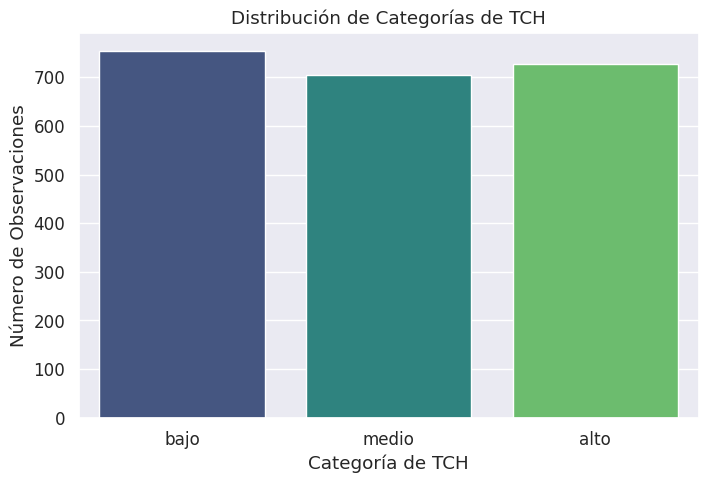

In [62]:
plt.figure(figsize=(8,5))
sns.countplot(x='tch_category',
              data=df,
              order=tch_labels,
              palette='viridis')
plt.title("Distribución de Categorías de TCH")
plt.xlabel("Categoría de TCH")
plt.ylabel("Número de Observaciones")
plt.show()

<ipython-input-63-f0d4c0186778>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sacarosa_category',


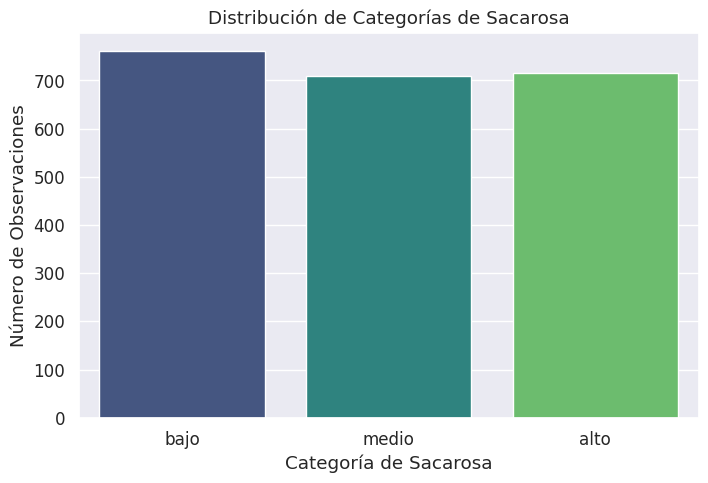

In [63]:
plt.figure(figsize=(8,5))
sns.countplot(x='sacarosa_category',
              data=df,
              order=sacarosa_labels,
              palette='viridis')
plt.title("Distribución de Categorías de Sacarosa")
plt.xlabel("Categoría de Sacarosa")
plt.ylabel("Número de Observaciones")
plt.show()

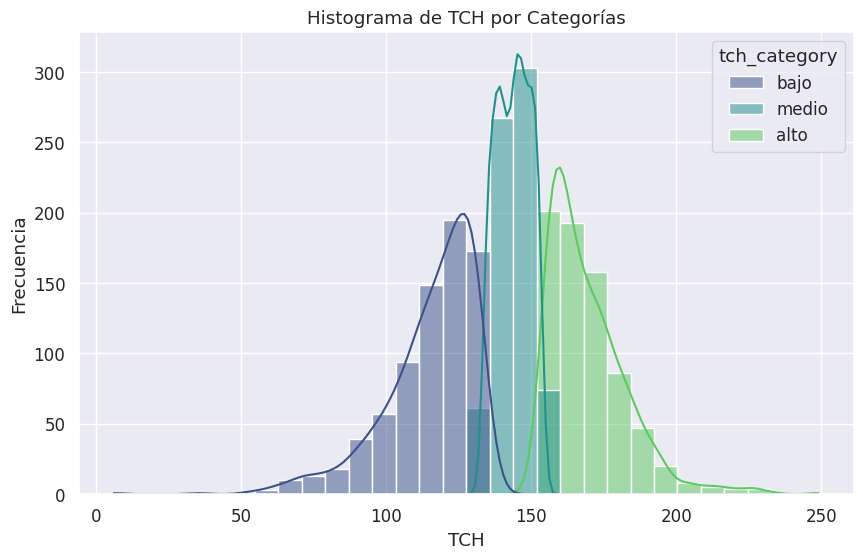

In [68]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,
             x='tch',
             hue='tch_category',
             bins=30,
             palette='viridis',
             kde=True)
plt.title("Histograma de TCH por Categorías")
plt.xlabel("TCH")
plt.ylabel("Frecuencia")
plt.show()

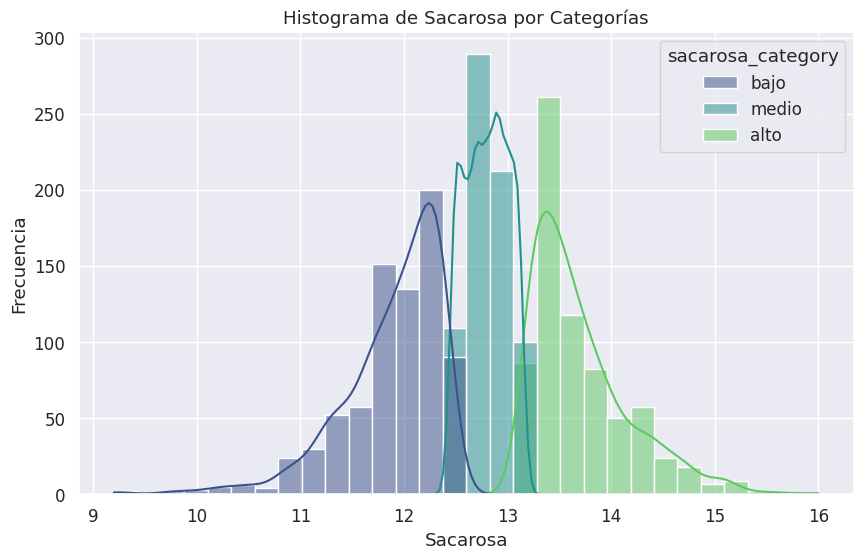

In [69]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,
             x='sacarosa',
             hue='sacarosa_category',
             bins=30,
             palette='viridis',
             kde=True)
plt.title("Histograma de Sacarosa por Categorías")
plt.xlabel("Sacarosa")
plt.ylabel("Frecuencia")
plt.show()

<ipython-input-70-7ec69fa54480>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tch_category',


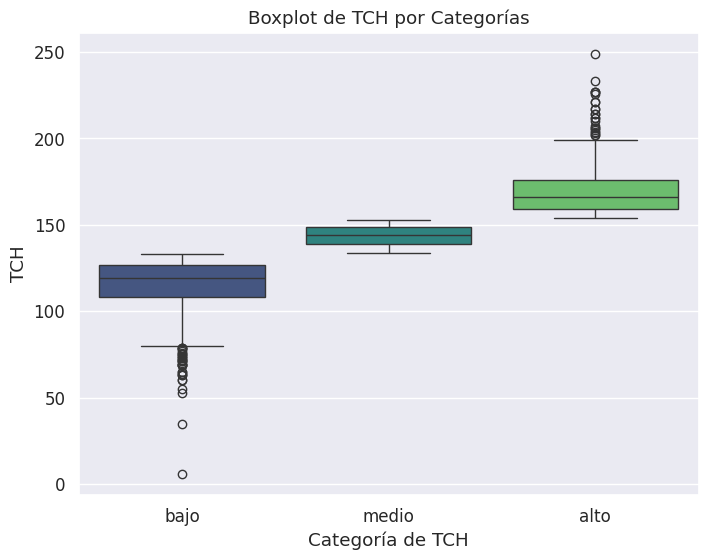

In [70]:
plt.figure(figsize=(8,6))
sns.boxplot(x='tch_category',
            y='tch',
            data=df,
            order=tch_labels,
            palette='viridis')
plt.title("Boxplot de TCH por Categorías")
plt.xlabel("Categoría de TCH")
plt.ylabel("TCH")
plt.show()

<ipython-input-72-1da9ae9ea287>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sacarosa_category',


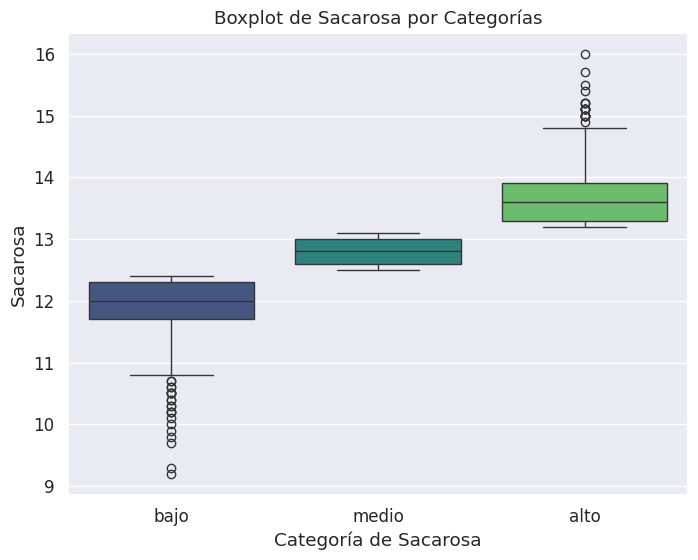

In [72]:
plt.figure(figsize=(8,6))
sns.boxplot(x='sacarosa_category',
            y='sacarosa',
            data=df,
            order=sacarosa_labels,
            palette='viridis')
plt.title("Boxplot de Sacarosa por Categorías")
plt.xlabel("Categoría de Sacarosa")
plt.ylabel("Sacarosa")
plt.show()

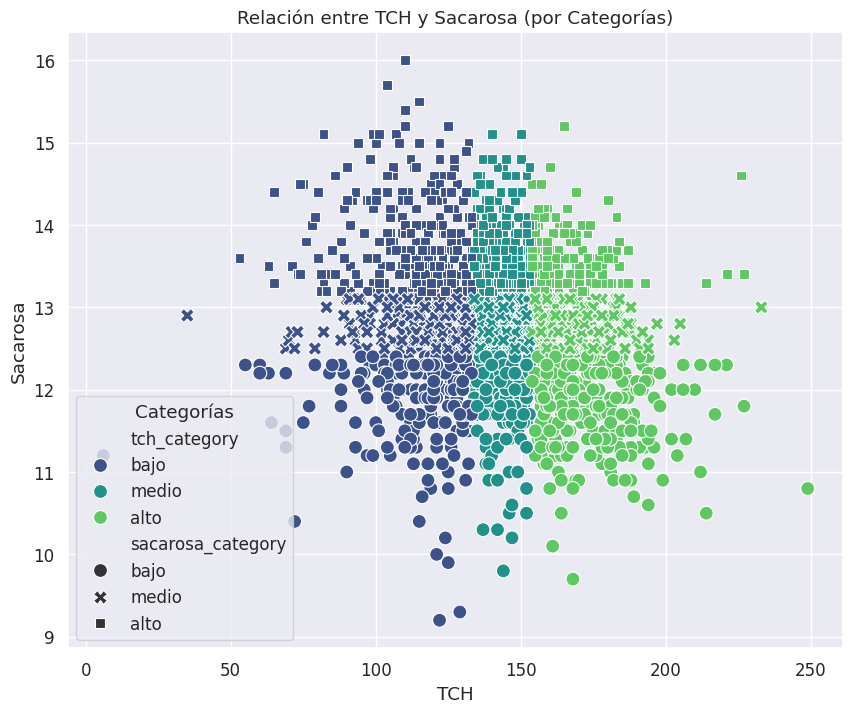

In [73]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_class,
                x='tch',
                y='sacarosa',
                hue='tch_category',
                style='sacarosa_category',
                palette='viridis',
                s=100)
plt.title("Relación entre TCH y Sacarosa (por Categorías)")
plt.xlabel("TCH")
plt.ylabel("Sacarosa")
plt.legend(title='Categorías')
plt.show()

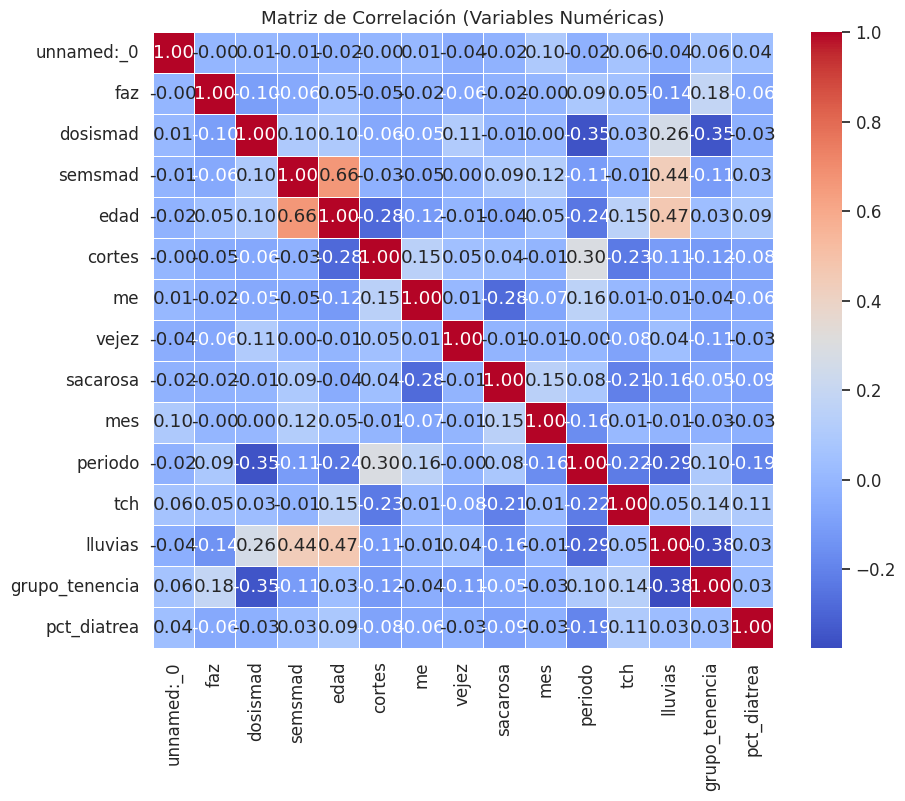

In [74]:
corr_matrix = df_class[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.show()

In [77]:
output_file = os.path.join(OUTPUT_DIR, "BD_IPSA_1940_formateado.csv")
df.to_csv(output_file, index=False)
print(f"El archivo formateado se ha exportado a: {output_file}")

El archivo formateado se ha exportado a: /content/drive/My Drive/AnaL/BD_IPSA_1940_formateado.csv
